# Install

In [1]:
# !pip install pytorchvideo torchvision torchmetrics --quiet
# !pip install av --quiet
# !pip install ultralytics
# !pip install decord av

# !pip install -q pillow torchvision

# Setup TSM

In [2]:
import os

# Create the directory structure
os.makedirs('ops_per_person', exist_ok=True)

# 1. Create the Temporal Shift Module logic
with open('ops_per_person/temporal_shift.py', 'w') as f:
    f.write("""
import torch
import torch.nn as nn

class TemporalShift(nn.Module):
    def __init__(self, net, n_segment=12, n_div=8):
        super(TemporalShift, self).__init__()
        self.net = net
        self.n_segment = n_segment
        self.fold_div = n_div

    def forward(self, x):
        x = self.shift(x, self.n_segment, self.fold_div)
        return self.net(x)

    @staticmethod
    def shift(x, n_segment, fold_div):
        nt, c, h, w = x.size()
        n_batch = nt // n_segment

        x = x.view(n_batch, n_segment, c, h, w)

        fold = c // fold_div
        out = x.clone()

        # Unidirectional shift (real-time friendly)
        out[:, 1:, :fold] = x[:, :-1, :fold]

        return out.view(nt, c, h, w)
""")

# 2. Create the Dataset logic (Simplified for your CCTV frames)
with open('ops_per_person/dataset.py', 'w') as f:
    f.write("""
import torch.utils.data as data
from PIL import Image
import os
import numpy as np
import random

class TSNDataSet(data.Dataset):
    def __init__(self, root_path, list_file, num_segments=12, transform=None, train=True):
        self.root_path = root_path
        self.list_file = list_file
        self.num_segments = num_segments
        self.transform = transform
        self.train = train
        self._parse_list()

    def _parse_list(self):
        self.video_list = []
        for line in open(self.list_file):
            parts = line.strip().rsplit(" ", 2)  # split from right!
            self.video_list.append(parts)

    def _get_indices(self, n_frames):
        if n_frames >= self.num_segments:
            if self.train:
                # jittered sampling
                segment_size = n_frames / self.num_segments
                offsets = []
                for i in range(self.num_segments):
                    start = int(segment_size * i)
                    end = int(segment_size * (i + 1))
                    offsets.append(random.randint(start, max(start, end - 1)))
                return offsets
            else:
                # deterministic (first & last included)
                return np.linspace(0, n_frames - 1, self.num_segments).astype(int)
        else:
            return [i % n_frames for i in range(self.num_segments)]

    def __getitem__(self, index):
        directory, n_frames, label = self.video_list[index]
        n_frames = int(n_frames)

        offsets = self._get_indices(n_frames)

        images = []
        for offset in offsets:
            frame_idx = offset + 1  # adjust if your dataset is 0-indexed
            p = os.path.join(self.root_path, directory, f"img_{frame_idx:05d}.jpg")

            if not os.path.exists(p):
                # fallback to last frame
                p = os.path.join(self.root_path, directory, f"img_{n_frames:05d}.jpg")

            images.append(Image.open(p).convert('RGB'))

        if self.transform:
            images = self.transform(images)

        return images, int(label)

    def __len__(self):
        return len(self.video_list)
""")

# 3. Create the simplified Model Wrapper
with open('ops_per_person/models.py', 'w') as f:
    f.write("""
import torch
import torch.nn as nn
from torchvision import models
from .temporal_shift import TemporalShift

class TSN(nn.Module):
    def __init__(self, num_class, num_segments=12):
        super(TSN, self).__init__()
        self.num_segments = num_segments

        self.base_model = models.mobilenet_v2(pretrained=True)

        # Apply TSM to selected layers (not all)
        for i, m in enumerate(self.base_model.features):
            if isinstance(m, nn.Sequential):
                self.base_model.features[i] = TemporalShift(
                    m,
                    n_segment=num_segments,
                    n_div=8
                )

        # Replace classifier
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.base_model.last_channel, num_class)
        )

    def forward(self, input):
        b, s, c, h, w = input.size()

        input = input.view(-1, c, h, w)
        base_out = self.base_model(input)

        base_out = base_out.view(b, s, -1)

        # Temporal consensus (average)
        return base_out.mean(dim=1)
""")

# 4. Group Transforms
with open('ops_per_person/transforms.py', 'w') as f:
    f.write("""
import torch
import torchvision.transforms.functional as F
import torchvision.transforms as T
import random

class GroupTransform:
    def __init__(self, size=(224, 224), is_train=True):
        self.size = size
        self.is_train = is_train

    def __call__(self, img_group):
        if self.is_train:
            do_flip = random.random() > 0.5
            brightness = random.uniform(0.7, 1.3)
            contrast = random.uniform(0.7, 1.3)

            do_perspective = random.random() > 0.5
            if do_perspective:
                persp_params = T.RandomPerspective.get_params(
                    width=img_group[0].size[0],
                    height=img_group[0].size[1],
                    distortion_scale=0.3
                )

            w, h = img_group[0].size
            th, tw = int(h * random.uniform(0.8, 1.0)), int(w * random.uniform(0.8, 1.0))
            i = random.randint(0, h - th)
            j = random.randint(0, w - tw)
        else:
            do_flip = do_perspective = False
            i, j, th, tw = 0, 0, img_group[0].size[1], img_group[0].size[0]
            brightness = contrast = 1.0

        transformed_group = []
        for img in img_group:
            img = F.resized_crop(img, i, j, th, tw, self.size)

            if self.is_train:
                if do_flip:
                    img = F.hflip(img)
                if do_perspective:
                    img = F.perspective(img, *persp_params, interpolation=T.InterpolationMode.BILINEAR)
                img = F.adjust_brightness(img, brightness)
                img = F.adjust_contrast(img, contrast)

            img = F.to_tensor(img)
            img = F.normalize(img, [0.485, 0.456, 0.406],
                                   [0.229, 0.224, 0.225])

            transformed_group.append(img)

        return torch.stack(transformed_group)
""")

print("✅ TSM structure created manually. You are ready to train!")

✅ TSM structure created manually. You are ready to train!


# Imports

In [3]:
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from collections import defaultdict
import torchvision.transforms as T
import zipfile

# Preprocess & Split Raw Dataset

In [4]:
import cv2
import os

# --- CONFIGURATION ---
# Where your .mp4 / .avi files are stored
raw_data_path = "dataset/ultimate_action_12fps_normal_and_violence"

# Where the extracted .jpg frames will go
output_frames_path = "dataset/frames_per_person"

# Updated classes
classes = ["normal", "violence"]

os.makedirs(output_frames_path, exist_ok=True)

print("🎬 Starting Clean Frame Extraction...")

for class_name in classes:
    class_folder = os.path.join(raw_data_path, class_name)

    if not os.path.exists(class_folder):
        print(f"⏩ Skipping {class_name}: Folder not found.")
        continue

    # Create class directory in output
    os.makedirs(os.path.join(output_frames_path, class_name), exist_ok=True)

    # Get all video files
    videos = [v for v in os.listdir(class_folder)
              if v.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]

    print(f"📂 Processing {class_name}: Found {len(videos)} videos")

    for v_name in videos:
        v_path = os.path.join(class_folder, v_name)

        # Folder for this video's frames
        video_base_name = os.path.splitext(v_name)[0]
        v_output_dir = os.path.join(output_frames_path, class_name, video_base_name)

        # Skip if already extracted
        if os.path.exists(v_output_dir) and len(os.listdir(v_output_dir)) > 5:
            continue

        os.makedirs(v_output_dir, exist_ok=True)

        cap = cv2.VideoCapture(v_path)
        count = 0

        if not cap.isOpened():
            print(f"❌ Failed to open: {v_path}")
            continue

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            count += 1

            frame_name = f"img_{count:05d}.jpg"
            cv2.imwrite(os.path.join(v_output_dir, frame_name), frame)

        cap.release()

    print(f"✅ Finished extracting frames for: {class_name}")

print("\n🚀 All frames extracted! You can now run the List Generator script.")

🎬 Starting Clean Frame Extraction...
📂 Processing normal: Found 947 videos
✅ Finished extracting frames for: normal
📂 Processing violence: Found 549 videos
✅ Finished extracting frames for: violence

🚀 All frames extracted! You can now run the List Generator script.


In [5]:
import os
import random

# --- CONFIGURATION ---
frames_root = "dataset/frames_per_person"
train_list_path = "train_list_per_person.txt"
test_list_path = "val_list_per_person.txt"

# Must match your model/dataset setup
num_segments = 12

# Updated classes
classes = ["normal", "violence"]
class_map = {class_name: idx for idx, class_name in enumerate(classes)}

all_entries = []

print("📝 Scanning frame directories and generating list files...")

# 1. Iterate through each class folder
for class_name, class_id in class_map.items():
    class_path = os.path.join(frames_root, class_name)

    if not os.path.exists(class_path):
        print(f"⚠️ Warning: {class_name} folder not found. Skipping.")
        continue

    # 2. Get each video folder within the class
    video_folders = [
        d for d in os.listdir(class_path)
        if os.path.isdir(os.path.join(class_path, d))
    ]

    included_count = 0

    for v_dir in video_folders:
        v_full_path = os.path.join(class_path, v_dir)

        # 3. Count total JPG frames
        n_frames = len([
            f for f in os.listdir(v_full_path)
            if f.lower().endswith(('.jpg', '.jpeg'))
        ])

        # 4. Ensure clip is long enough
        if n_frames >= num_segments:
            all_entries.append(f"{class_name}/{v_dir} {n_frames} {class_id}")
            included_count += 1

    print(f"✅ Class '{class_name}': {included_count} valid clips indexed.")

# 5. Shuffle before split
random.seed(42)
random.shuffle(all_entries)

# 6. 80/20 split
split_idx = int(len(all_entries) * 0.8)
train_list = all_entries[:split_idx]
test_list = all_entries[split_idx:]

# 7. Save files
with open(train_list_path, "w") as f:
    f.write("\n".join(train_list))

with open(test_list_path, "w") as f:
    f.write("\n".join(test_list))

print("-" * 30)
print("✨ Success! Dataset list files created.")
print(f"📊 Total Valid Clips: {len(all_entries)}")
print(f"📂 Train: {len(train_list)} clips saved to {train_list_path}")
print(f"📂 Test: {len(test_list)} clips saved to {test_list_path}")

📝 Scanning frame directories and generating list files...
✅ Class 'normal': 812 valid clips indexed.
✅ Class 'violence': 515 valid clips indexed.
------------------------------
✨ Success! Dataset list files created.
📊 Total Valid Clips: 1327
📂 Train: 1061 clips saved to train_list_per_person.txt
📂 Test: 266 clips saved to val_list_per_person.txt


# Train

In [6]:
import os
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader
from ops_per_person.dataset import TSNDataSet
from ops_per_person.transforms import GroupTransform
from ops_per_person.models import TSN

import matplotlib.pyplot as plt
import csv

# --- CONFIG ---
NUM_CLASSES = 2
NUM_SEGMENTS = 12
BATCH_SIZE = 16
ACCUMULATION_STEPS = 4
EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

SAVE_DIR = "models_per_person"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- DATA ---
train_dataset = TSNDataSet(
    "dataset/frames_per_person",
    "train_list_per_person.txt",
    num_segments=NUM_SEGMENTS,
    transform=GroupTransform(is_train=True),
    train=True
)

val_dataset = TSNDataSet(
    "dataset/frames_per_person",
    "val_list_per_person.txt",
    num_segments=NUM_SEGMENTS,
    transform=GroupTransform(is_train=False),
    train=False
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# --- CLASS WEIGHTS ---
with open("train_list_per_person.txt", "r") as f:
    lines = f.readlines()
    normal_c = sum(1 for line in lines if line.strip().endswith(' 0'))
    viol_c = sum(1 for line in lines if line.strip().endswith(' 1'))
    normal_c = normal_c if normal_c > 0 else 1
    viol_c = viol_c if viol_c > 0 else 1
    class_counts = [normal_c, viol_c]
weights = [1.0 / c for c in class_counts]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = False
class_weights = torch.tensor(weights).float().to(device)

# --- MODEL ---
model = TSN(num_class=NUM_CLASSES, num_segments=NUM_SEGMENTS).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.0005, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

# --- LOG STORAGE ---
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

csv_path = os.path.join(SAVE_DIR, "training_log_per_person.csv")

# --- EARLY STOPPING SETUP ---
best_acc = 0.0
early_stop_counter = 0

# --- TRAIN LOOP ---
for epoch in range(EPOCHS):

    # ---------- TRAIN ----------
    model.train()
    train_loss_total = 0
    train_correct = 0
    train_total = 0

    optimizer.zero_grad()
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        (loss / ACCUMULATION_STEPS).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad()

        train_loss_total += loss.item() * labels.size(0)
        train_correct += outputs.argmax(1).eq(labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_total / train_total
    train_acc = train_correct / train_total

    # ---------- VALIDATION ----------
    model.eval()
    val_loss_total = 0
    val_total = 0

    TP = FP = TN = FN = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            val_loss_total += loss.item() * labels.size(0)
            val_total += labels.size(0)

            for p, l in zip(preds, labels):
                if p == 1 and l == 1:
                    TP += 1
                elif p == 1 and l == 0:
                    FP += 1
                elif p == 0 and l == 0:
                    TN += 1
                elif p == 0 and l == 1:
                    FN += 1

    val_loss = val_loss_total / val_total
    val_acc = (TP + TN) / val_total

    # --- METRICS ---
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    # --- SAVE HISTORY ---
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)

    # --- PRINT ---
    print(f"Epoch {epoch+1}: "
          f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
          f"Acc {val_acc*100:.2f}% | "
          f"P {precision:.3f} | R {recall:.3f} | F1 {f1:.3f}")

    scheduler.step(val_acc)

    # --- SAVE BEST + EARLY STOP RESET ---
    if val_acc > best_acc:
        best_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "tsm_best_per_person.pth"))
        print(f"⭐ New Best: {best_acc*100:.2f}%")
    else:
        early_stop_counter += 1
        print(f"⏳ Early Stop Counter: {early_stop_counter}/{EARLY_STOPPING_PATIENCE}")

    # --- EARLY STOPPING CHECK ---
    if early_stop_counter >= EARLY_STOPPING_PATIENCE:
        print("🛑 Early stopping triggered")
        break

    # --- SAVE CSV ---
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(history.keys())
        writer.writerows(zip(*history.values()))

    # --- PLOT ---
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(history["val_acc"], label="Accuracy")
    plt.plot(history["f1"], label="F1")
    plt.legend()
    plt.title("Metrics")

    plt.savefig(os.path.join(SAVE_DIR, "training_plot_per_person.png"))
    plt.close()

/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss 0.6577 | Val Loss 0.5666 | Acc 83.83% | P 0.767 | R 0.860 | F1 0.811
⭐ New Best: 83.83%
Epoch 2: Train Loss 0.5787 | Val Loss 0.4649 | Acc 80.45% | P 0.698 | R 0.907 | F1 0.789
⏳ Early Stop Counter: 1/5
Epoch 3: Train Loss 0.5189 | Val Loss 0.4345 | Acc 84.96% | P 0.868 | R 0.738 | F1 0.798
⭐ New Best: 84.96%
Epoch 4: Train Loss 0.4617 | Val Loss 0.3726 | Acc 83.83% | P 0.771 | R 0.850 | F1 0.809
⏳ Early Stop Counter: 1/5
Epoch 5: Train Loss 0.4528 | Val Loss 0.3586 | Acc 83.46% | P 0.760 | R 0.860 | F1 0.807
⏳ Early Stop Counter: 2/5
Epoch 6: Train Loss 0.4221 | Val Loss 0.3483 | Acc 84.59% | P 0.795 | R 0.832 | F1 0.813
⏳ Early Stop Counter: 3/5
Epoch 7: Train Loss 0.4033 | Val Loss 0.3374 | Acc 86.84% | P 0.860 | R 0.804 | F1 0.831
⭐ New Best: 86.84%
Epoch 8: Train Loss 0.3757 | Val Loss 0.3228 | Acc 86.09% | P 0.830 | R 0.822 | F1 0.826
⏳ Early Stop Counter: 1/5
Epoch 9: Train Loss 0.3685 | Val Loss 0.3244 | Acc 89.10% | P 0.898 | R 0.822 | F1 0.859
⭐ New Best: 

# Generate Confusion Matrix of particular model

📥 Loading model weights...
🚀 Running inference on validation set...


/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Processing batch 0...
Processing batch 10...


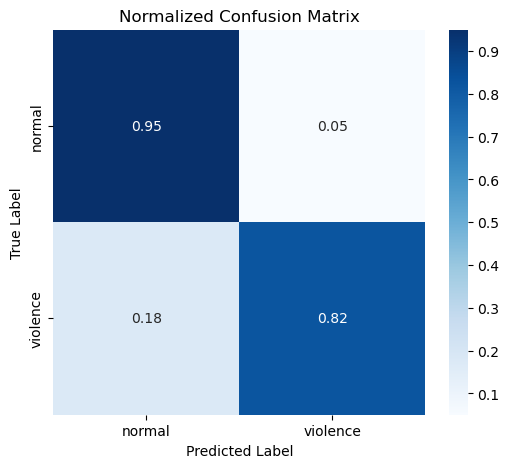

✅ Confusion matrix saved to: models_per_person/confusion_matrix_per_person.png


In [7]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

from ops_per_person.models import TSN
from ops_per_person.dataset import TSNDataSet
from ops_per_person.transforms import GroupTransform

# --- SETTINGS ---
MODEL_PATH = "models_per_person/tsm_best_per_person.pth"
SAVE_DIR = "models_per_person"
NUM_CLASSES = 2
NUM_SEGMENTS = 12
BATCH_SIZE = 16

CLASS_NAMES = ["normal", "violence"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_cm():
    # 1. Load Model
    print("📥 Loading model weights...")
    model = TSN(num_class=NUM_CLASSES, num_segments=NUM_SEGMENTS)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE).eval()

    # 2. Dataset
    val_dataset = TSNDataSet(
        "dataset/frames_per_person",
        "val_list_per_person.txt",
        num_segments=NUM_SEGMENTS,
        transform=GroupTransform(is_train=False)
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    # 3. Inference
    all_preds = []
    all_targets = []

    print("🚀 Running inference on validation set...")

    with torch.no_grad():
        for i, (inputs, targets) in enumerate(val_loader):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())

            if i % 10 == 0:
                print(f"Processing batch {i}...")

    # 4. Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # 5. Plot
    plt.figure(figsize=(6, 5))  # smaller since only 2 classes
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title("Normalized Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")

    # 6. Save
    os.makedirs(SAVE_DIR, exist_ok=True)
    save_path = os.path.join(SAVE_DIR, "confusion_matrix_per_person.png")

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Confusion matrix saved to: {save_path}")

    torch.cuda.empty_cache()


if __name__ == "__main__":
    generate_cm()